# ZEMAWI Ethiopian Food Price Watch
## 1. Data Cleaning and Preprocessing

**Project:** An early-warning dashboard for Teff, Maize and Wheat across Ethiopian markets

**Dataset:** WFP Ethiopia Food Prices

**Purpose:** Clean, validate, and prepare historical food price data for early-warning analysis and dashboard development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data_path = "../data/raw/wfp_food_prices_eth.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (62880, 16)


First and last rows

In [3]:
df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2000-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Maize (white),67,100 KG,actual,Wholesale,ETB,120.75,15.08
1,2000-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Sorghum (white),135,100 KG,actual,Wholesale,ETB,187.25,23.39
2,2000-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Teff,308,100 KG,actual,Wholesale,ETB,222.00,27.73
3,2000-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Wheat,84,100 KG,actual,Wholesale,ETB,168.75,21.08
4,2000-01-15,Amhara,Administrative unit not available,Baher Dar,482,11.60,37.38,cereals and tubers,Maize (white),67,100 KG,actual,Wholesale,ETB,115.50,14.43


In [4]:
df.tail()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
62875,2023-07-15,Amhara,W. HAMRA,Sekota,497,12.63,39.03,cereals and tubers,Teff (Sergegna),779,100 KG,aggregate,Retail,ETB,5000.0,91.45
62876,2023-07-15,Amhara,W. HAMRA,Sekota,497,12.63,39.03,cereals and tubers,Wheat flour,58,100 KG,aggregate,Retail,ETB,5000.0,91.45
62877,2023-07-15,Amhara,W. HAMRA,Sekota,497,12.63,39.03,"meat, fish and eggs",Livestock (Sheep),390,Head,aggregate,Retail,ETB,3500.0,64.02
62878,2023-07-15,Amhara,W. HAMRA,Sekota,497,12.63,39.03,miscellaneous food,Sugar,97,KG,aggregate,Retail,ETB,80.0,1.46
62879,2023-07-15,Amhara,W. HAMRA,Sekota,497,12.63,39.03,oil and fats,Oil (vegetable),96,L,aggregate,Retail,ETB,210.0,3.84


Inspect columns

In [5]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 62880
Number of columns: 16


In [6]:
print("Column names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column names:
1. date
2. admin1
3. admin2
4. market
5. market_id
6. latitude
7. longitude
8. category
9. commodity
10. commodity_id
11. unit
12. priceflag
13. pricetype
14. currency
15. price
16. usdprice


Inspect data types

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62880 entries, 0 to 62879
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          62880 non-null  object 
 1   admin1        62875 non-null  object 
 2   admin2        62875 non-null  object 
 3   market        62880 non-null  object 
 4   market_id     62880 non-null  int64  
 5   latitude      62875 non-null  float64
 6   longitude     62875 non-null  float64
 7   category      62880 non-null  object 
 8   commodity     62880 non-null  object 
 9   commodity_id  62880 non-null  int64  
 10  unit          62880 non-null  object 
 11  priceflag     62880 non-null  object 
 12  pricetype     62880 non-null  object 
 13  currency      62880 non-null  object 
 14  price         62880 non-null  float64
 15  usdprice      62880 non-null  float64
dtypes: float64(4), int64(2), object(10)
memory usage: 7.7+ MB


In [8]:
dtype_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_values": df.isna().sum().values,
    "unique_values": df.nunique().values
})

dtype_summary

,column,dtype,missing_values,unique_values
0,date,object,0,318
1,admin1,object,5,11
2,admin2,object,5,60
3,market,object,0,129
4,market_id,int64,0,129
5,latitude,float64,5,117
6,longitude,float64,5,110
7,category,object,0,8
8,commodity,object,0,96
9,commodity_id,int64,0,96


Check date range

In [9]:
print("First date:", df["date"].min())
print("Last date:", df["date"].max())

First date: 2000-01-15
Last date: 2026-07-15


1.8 Check commodities

In [10]:
print("Number of unique commodities:", df["commodity"].nunique())

Number of unique commodities: 96


In [11]:
commodity_counts = (
    df["commodity"]
    .value_counts()
    .reset_index()
)

commodity_counts.columns = [
    "commodity",
    "observations"
]

commodity_counts

,commodity,observations
0,Maize (white),8648
1,Wheat,4304
2,Livestock (Goat),3192
3,Livestock (Sheep),3046
4,Wheat (white),2534
5,Sorghum (white),2130
6,Sorghum,2088
7,Wage (casual labour),1963
8,Rice,1748
9,Beans (fava),1707


1.9 Check markets

In [12]:
print("Number of unique markets:", df["market"].nunique())

Number of unique markets: 129


In [13]:
market_counts = (
    df["market"]
    .value_counts()
    .reset_index()
)

market_counts.columns = [
    "market",
    "observations"
]

market_counts

,market,observations
0,Diredawa,2269
1,Addis Ababa,1937
2,Gode,1866
3,Babile,1779
4,Mekele,1607
...,...,...
124,Humera,27
125,Kemashi,18
126,Erer,7
127,Bichena,5


check whether each market name corresponds consistently to one market ID

In [14]:
market_id_check = (
    df.groupby("market_id")["market"]
      .nunique()
      .sort_values(ascending=False)
)

market_id_check.head(20)

market_id
458    1
459    1
460    1
461    1
462    1
463    1
464    1
465    1
466    1
467    1
468    1
469    1
470    1
471    1
472    1
473    1
474    1
475    1
476    1
477    1
Name: market, dtype: int64

reverse

In [15]:
market_name_check = (
    df.groupby("market")["market_id"]
      .nunique()
      .sort_values(ascending=False)
)

market_name_check.head(20)

market
Abaala                    1
Abi Adi                   1
Abomsa                    1
Addis Ababa               1
Adighageray               1
Adigrat                   1
Adiha (Ayder Sub City)    1
Adihaqui                  1
Adwa                      1
Ajeber                    1
Alaba                     1
Alamata                   1
Aleta Wondo               1
Amaro                     1
Ambo                      1
Amdework                  1
Arba Minch                1
Aroresa                   1
Asayta                    1
Assela                    1
Name: market_id, dtype: int64

1.10 Check regions

In [16]:
print("Number of unique regions:", df["admin1"].nunique())

Number of unique regions: 11


In [17]:
region_counts = (
    df["admin1"]
    .value_counts(dropna=False)
    .reset_index()
)

region_counts.columns = [
    "region",
    "observations"
]

region_counts

,region,observations
0,Oromia,18781
1,Amhara,11663
2,Tigray,8736
3,Somali,7615
4,Afar,4266
5,SNNPR,4235
6,Dire Dawa,2269
7,Addis Ababa,1937
8,Gambela,1430
9,Harari,1199


1.11 Check admin2 areas

In [18]:
print("Number of admin2 areas:", df["admin2"].nunique())

Number of admin2 areas: 60


In [19]:
print("Admin2 areas:")
print(sorted(df["admin2"].dropna().unique()))

Admin2 areas:
['AA ZONE1', 'AFDER', 'ALABA SW', 'AMARO SW', 'ARSI', 'ASOSA', 'Administrative unit not available', 'BALE', 'BORENA', 'C. TIGRAY', 'DIRE DAWA', 'E. GOJAM', 'E. HARERGE', 'E. SHEWA', 'E. TIGRAY', 'E. WELLEGA', 'GAMO GOFA', 'GEDEO', 'GODE', 'GODERE', 'GUJI', 'GURAGE', 'HADIYA', 'HARAR/HUNDENE', 'JIJIGA', 'JIMMA', 'KAMASHI', 'KONSO SW', 'KORAHE', 'LIBEN', 'MEKELE', 'METEKEL', 'N. GONDER', 'N. SHEWA (R3)', 'N. SHEWA (R4)', 'N. WELLO', 'NW. TIGRAY', 'OROMIYA', 'S. GONDER', 'S. TIGRAY', 'S. WELLO', 'S.W. SHEWA', 'SELTI', 'SHINILE', 'SIDAMA', 'SOUTH OMO', 'W. GOJAM', 'W. HAMRA', 'W. HARERGE', 'W. TIGRAY', 'WELAYITA', 'WEST SHEWA', 'ZONE 1', 'ZONE 2', 'ZONE 3', 'ZONE1', 'ZONE2', 'ZONE3', 'ZONE4', 'ZONE5']


1.12 Check frequency

In [20]:
temp_date = pd.to_datetime(df["date"], errors="coerce")
print(temp_date.sort_values().diff().value_counts().head(10))

date
0 days     62562
31 days      184
30 days      105
28 days       20
29 days        7
61 days        1
Name: count, dtype: int64


1.13 Check units

In [21]:
print("Units:")
print(df["unit"].value_counts())

print("\nCommodity and unit:")
print(
    df.groupby(["commodity", "unit"])
    .size()
    .sort_values(ascending=False)
)

Units:
unit
100 KG     32966
KG         13812
Head        8971
L           4370
Day         2076
Unit         603
USD/LCU       82
Name: count, dtype: int64

Commodity and unit:
commodity                    unit  
Maize (white)                100 KG    8648
Wheat                        100 KG    4304
Livestock (Goat)             Head      3192
Livestock (Sheep)            Head      3046
Wheat (white)                100 KG    2414
                                       ... 
Beans (mung)                 100 KG       3
Beans (haricot, white)       100 KG       2
Beans (haricot, red)         100 KG       1
Potatoes (Irish)             KG           1
Wage (non-qualified labour)  Day          1
Length: 104, dtype: int64


### Check price types

In [22]:
print(df["pricetype"].value_counts(),"\n")

print(
    df.groupby(["commodity", "pricetype"])
    .size()
    .sort_values(ascending=False)
)

pricetype
Retail       53949
Wholesale     8931
Name: count, dtype: int64 

commodity                    pricetype
Maize (white)                Retail       6015
Livestock (Goat)             Retail       3192
Livestock (Sheep)            Retail       3046
Maize (white)                Wholesale    2633
Wheat                        Retail       2389
                                          ... 
Beans (haricot, white)       Wholesale       2
Beans (haricot, red)         Wholesale       1
Potatoes (Irish)             Retail          1
Sesame                       Wholesale       1
Wage (non-qualified labour)  Retail          1
Length: 112, dtype: int64


1.14 Check duplicates

In [23]:
exact_duplicates = df.duplicated().sum()

print("Number of exact duplicate rows:", exact_duplicates)

Number of exact duplicate rows: 0


### Check missing values

In [24]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100
})

print(missing[missing["missing_count"] > 0])

           missing_count  missing_percentage
admin1                 5            0.007952
admin2                 5            0.007952
latitude               5            0.007952
longitude              5            0.007952


### Check suspicious values

In [25]:
df.describe()

,market_id,latitude,longitude,commodity_id,price,usdprice
count,62880.000000,62875.000000,62875.000000,62880.000000,62880.000000,62880.000000
mean,1968.619609,9.658493,39.761395,254.267144,4786.689269,65.167258
std,2184.045691,2.633341,1.883684,240.552460,10264.994468,108.259048
min,458.000000,3.530000,33.950000,50.000000,0.880000,0.069000
25%,475.000000,7.930000,38.580000,81.000000,130.787500,1.810000
50%,499.000000,9.320000,39.630000,135.000000,1257.250000,39.280000
75%,3649.000000,11.670000,41.420000,383.000000,5464.250000,79.510000
max,10522.000000,14.450000,44.280000,1314.000000,270000.000000,1736.170000


In [26]:
print(df["price"].describe())

count     62880.000000
mean       4786.689269
std       10264.994468
min           0.880000
25%         130.787500
50%        1257.250000
75%        5464.250000
max      270000.000000
Name: price, dtype: float64


In [27]:
print("Zero prices:", (df["price"] == 0).sum())
print("Negative prices:", (df["price"] < 0).sum())

Zero prices: 0
Negative prices: 0


### Initial data dictionary

In [28]:
data_dictionary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isna().sum().values
})

data_dictionary

,Column,Data Type,Missing Values
date,date,object,0
admin1,admin1,object,5
admin2,admin2,object,5
market,market,object,0
market_id,market_id,int64,0
latitude,latitude,float64,5
longitude,longitude,float64,5
category,category,object,0
commodity,commodity,object,0
commodity_id,commodity_id,int64,0


## Creating clean dataset

In [29]:
clean_df = df.copy()

print("Cleaning dataset created.")
print("Shape:", clean_df.shape)

Cleaning dataset created.
Shape: (62880, 16)


### Standardize column names

In [30]:
clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(clean_df.columns.tolist())

['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice']


### Convert dates

In [31]:
clean_df["date"] = pd.to_datetime(
    clean_df["date"],
    errors="coerce"
)

print(clean_df["date"].dtype)

datetime64[ns]


In [32]:
print("Start:", clean_df["date"].min())
print("End:", clean_df["date"].max())

Start: 2000-01-15 00:00:00
End: 2026-07-15 00:00:00


### Sort chronologically

In [33]:
clean_df = clean_df.sort_values("date").reset_index(drop=True)

print("Data sorted by date.")

Data sorted by date.


### Standardize commodity names

In [34]:
clean_df["commodity"] = clean_df["commodity"].str.strip()

print(clean_df["commodity"].unique())

['Maize (white)' 'Sorghum (white)' 'Teff' 'Wheat' 'Sorghum (red)'
 'Sorghum' 'Beans (fava, dry)' 'Peas (green, dry)' 'Pasta'
 'Rice (imported)' 'Lentils' 'Sugar' 'Milk' 'Chickpeas' 'Fuel (kerosene)'
 'Fuel (petrol-gasoline)' 'Fuel (diesel)' 'Wheat flour' 'Barley'
 'Sweet potatoes' 'Beans (haricot)' 'Livestock (Goat)'
 'Wage (non-qualified labour)' 'Livestock (Sheep)'
 'Corn Soy Blend (CSB++, food aid)' 'Exchange rate (unofficial)' 'Rice'
 'Oil (palm)' 'Sesame' 'Beans' 'Wage (qualified labour)'
 'Maize (food aid)' 'Wheat (food aid)' 'Coffee' 'Livestock (bull)'
 'Livestock (camel)' 'Wage (casual labour)' 'Oil (vegetable)'
 'Wheat (white)' 'Peas' 'Potatoes' 'Teff (red)' 'Teff (white)'
 'Groundnuts' 'Livestock (cattle)' 'Peas (split, dry)' 'Beans (fava)'
 'Taro' 'Potatoes (Irish)' 'Bananas' 'Sorghum (food aid)' 'Livestock (ox)'
 'Teff (mixed)' 'Millet (finger)' 'Livestock (donkey)' 'Cabbage' 'Carrots'
 'Kale' 'Mangoes' 'Onions' 'Oranges' 'Papaya' 'Peppers (green)' 'Tomatoes'
 'Lettuce' 'Ga

### Standardize market names

In [35]:
clean_df["market"] = clean_df["market"].str.strip()

print("Markets:", clean_df["market"].nunique())

Markets: 129


### Standardize units

In [36]:
clean_df["unit"] = clean_df["unit"].str.strip()

print(clean_df["unit"].value_counts())

unit
100 KG     32966
KG         13812
Head        8971
L           4370
Day         2076
Unit         603
USD/LCU       82
Name: count, dtype: int64


### Handle missing values

In [37]:
missing = pd.DataFrame({
    "missing_count": clean_df.isna().sum(),
    "missing_percentage": clean_df.isna().mean() * 100
})

print(missing[missing["missing_count"] > 0])

           missing_count  missing_percentage
admin1                 5            0.007952
admin2                 5            0.007952
latitude               5            0.007952
longitude              5            0.007952


### Investigate outliers

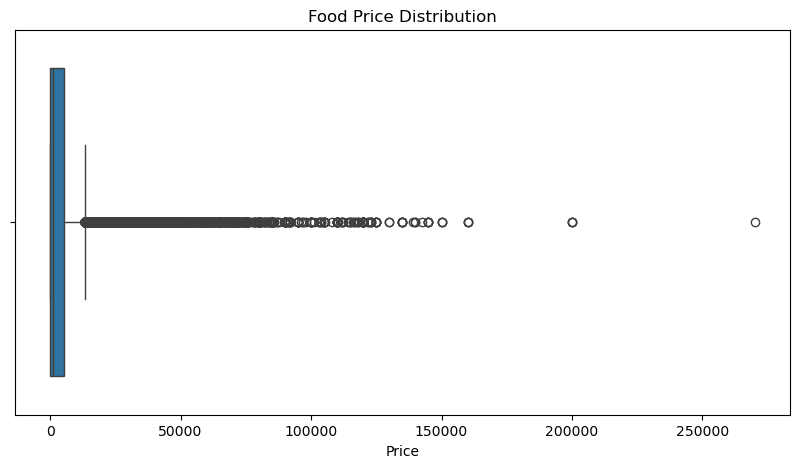

In [38]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=clean_df["price"])

plt.title("Food Price Distribution")
plt.xlabel("Price")

plt.show()

In [39]:
clean_df["price"].describe()

count     62880.000000
mean       4786.689269
std       10264.994468
min           0.880000
25%         130.787500
50%        1257.250000
75%        5464.250000
max      270000.000000
Name: price, dtype: float64

### Identify impossible values

In [40]:
print("Negative prices:", (clean_df["price"] < 0).sum())
print("Zero prices:", (clean_df["price"] == 0).sum())

Negative prices: 0
Zero prices: 0


### Check gaps in time

In [41]:
dates = clean_df["date"].dropna().sort_values().drop_duplicates()

date_gaps = dates.diff()

print(date_gaps.value_counts().head(10))

date
31 days    184
30 days    105
28 days     20
29 days      7
61 days      1
Name: count, dtype: int64


### Create our three target commodity groups

In [42]:
clean_df["commodity_group"] = "Other"

clean_df.loc[
    clean_df["commodity"].str.contains("Teff", case=False, na=False),
    "commodity_group"
] = "Teff"

clean_df.loc[
    clean_df["commodity"].str.contains("Maize", case=False, na=False),
    "commodity_group"
] = "Maize"

clean_df.loc[
    clean_df["commodity"].str.contains("Wheat", case=False, na=False),
    "commodity_group"
] = "Wheat"


print(clean_df["commodity_group"].value_counts())

commodity_group
Other    42138
Wheat     8759
Maize     8704
Teff      3279
Name: count, dtype: int64


In [43]:
target_df = clean_df[
    clean_df["commodity_group"].isin(["Teff", "Maize", "Wheat"])
].copy()

print("Target dataset shape:", target_df.shape)

print("\nTarget groups:")
print(target_df["commodity_group"].value_counts())

Target dataset shape: (20742, 17)

Target groups:
commodity_group
Wheat    8759
Maize    8704
Teff     3279
Name: count, dtype: int64


exclude wheat flour

In [44]:
print(
    target_df["commodity"].value_counts()
)

commodity
Maize (white)       8648
Wheat               4304
Wheat (white)       2534
Wheat flour         1627
Teff (white)        1035
Teff (mixed)         796
Teff                 603
Teff (Sergegna)      521
Teff (red)           324
Wheat (food aid)     152
Wheat (mixed)        142
Maize (food aid)      35
Maize (yellow)        21
Name: count, dtype: int64


In [45]:
target_df = target_df[
    target_df["commodity"] != "Wheat flour"
].copy()

In [46]:
print(
    target_df["commodity"].value_counts()
)

commodity
Maize (white)       8648
Wheat               4304
Wheat (white)       2534
Teff (white)        1035
Teff (mixed)         796
Teff                 603
Teff (Sergegna)      521
Teff (red)           324
Wheat (food aid)     152
Wheat (mixed)        142
Maize (food aid)      35
Maize (yellow)        21
Name: count, dtype: int64


Convert KG prices

In [47]:
kg_rows = target_df["unit"] == "KG"

target_df.loc[kg_rows, "price"] = target_df.loc[kg_rows, "price"] * 100
target_df.loc[kg_rows, "usdprice"] = target_df.loc[kg_rows, "usdprice"] * 100

target_df.loc[kg_rows, "unit"] = "100 KG"

In [48]:
print(target_df["unit"].value_counts())

unit
100 KG    19115
Name: count, dtype: int64


There is no mixed unit

In [49]:
print(
    target_df.groupby(["commodity", "unit"]).size()
)

commodity         unit  
Maize (food aid)  100 KG      35
Maize (white)     100 KG    8648
Maize (yellow)    100 KG      21
Teff              100 KG     603
Teff (Sergegna)   100 KG     521
Teff (mixed)      100 KG     796
Teff (red)        100 KG     324
Teff (white)      100 KG    1035
Wheat             100 KG    4304
Wheat (food aid)  100 KG     152
Wheat (mixed)     100 KG     142
Wheat (white)     100 KG    2534
dtype: int64


In [50]:
target_df.nlargest(20, "price")[
    ["date", "market", "admin1", "commodity", "unit", "pricetype", "price"]
]

,date,market,admin1,commodity,unit,pricetype,price
53388,2025-08-15,Mechara,Oromia,Wheat (white),100 KG,Retail,20000.0
53915,2025-08-15,Bedessa,Oromia,Wheat (white),100 KG,Retail,20000.0
57956,2026-02-15,Dolo Ado,Somali,Maize (white),100 KG,Retail,20000.0
58674,2026-03-15,Dolo Ado,Somali,Maize (white),100 KG,Retail,20000.0
54051,2025-09-15,Gubiya/yalo,Afar,Teff (white),100 KG,Retail,18000.0
55135,2025-10-15,Gubiya/yalo,Afar,Teff (white),100 KG,Retail,18000.0
57190,2026-01-15,Gubiya/yalo,Afar,Teff (white),100 KG,Retail,17500.0
57999,2026-02-15,Gubiya/yalo,Afar,Teff (white),100 KG,Retail,17500.0
58174,2026-02-15,Shahigubi,Afar,Teff (white),100 KG,Retail,17500.0
58817,2026-03-15,Gubiya/yalo,Afar,Teff (white),100 KG,Retail,17500.0


In [51]:
target_df.groupby("commodity_group")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
commodity_group,,,,,,,,
Maize,8704.0,1882.124646,2028.645858,29.60,445.0,776.0,3232.25,20000.0
Teff,3279.0,5487.253175,3880.623168,66.00,3343.5,4130.0,8052.50,18000.0
Wheat,7132.0,2760.434356,3048.770541,1.74,254.0,1600.0,4600.00,20000.0


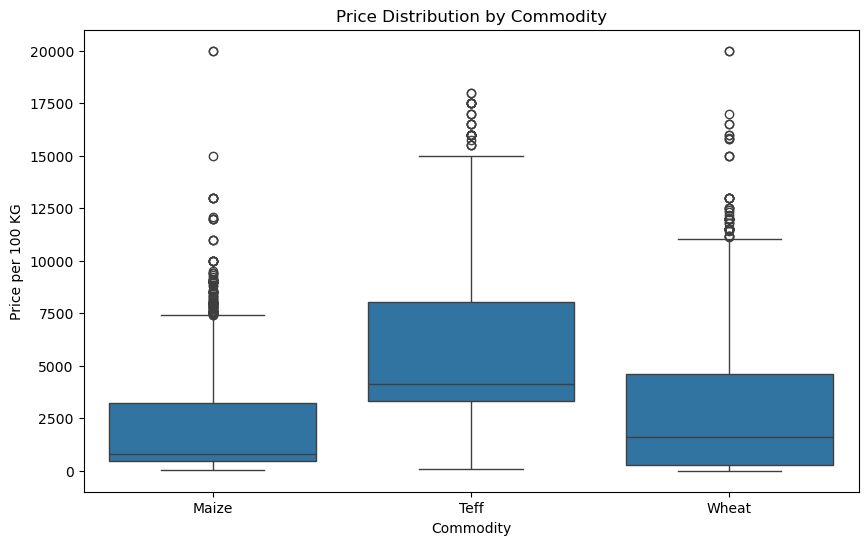

In [52]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=target_df,
    x="commodity_group",
    y="price"
)

plt.title("Price Distribution by Commodity")
plt.xlabel("Commodity")
plt.ylabel("Price per 100 KG")

plt.show()

In [53]:
dates = target_df["date"].drop_duplicates().sort_values()

gaps = dates.diff()

print(gaps[gaps > pd.Timedelta(days=45)])

12573   61 days
47848   61 days
Name: date, dtype: timedelta64[ns]


In [54]:
print("Number of unique dates:", target_df["date"].nunique())

print("\nFirst 10 dates:")
print(target_df["date"].drop_duplicates().sort_values().head(10))

print("\nLast 10 dates:")
print(target_df["date"].drop_duplicates().sort_values().tail(10))

Number of unique dates: 317

First 10 dates:
0    2000-01-15
7    2000-02-15
14   2000-03-15
21   2000-04-15
28   2000-05-15
35   2000-06-15
42   2000-07-15
49   2000-08-15
56   2000-09-15
63   2000-10-15
Name: date, dtype: datetime64[ns]

Last 10 dates:
54773   2025-10-15
55433   2025-11-15
56117   2025-12-15
56806   2026-01-15
57576   2026-02-15
58389   2026-03-15
59170   2026-04-15
60036   2026-05-15
60824   2026-06-15
61867   2026-07-15
Name: date, dtype: datetime64[ns]


In [55]:
dates = target_df["date"].drop_duplicates().sort_values()

gaps = dates.diff()

print(gaps.value_counts())

date
31 days    183
30 days    104
28 days     20
29 days      7
61 days      2
Name: count, dtype: int64


In [56]:
print(
    pd.DataFrame({
        "date": dates,
        "gap": dates.diff()
    }).query("gap > '45 days'")
)

            date     gap
12573 2019-07-15 61 days
47848 2025-01-15 61 days


In [57]:
print(
    all_dates[
        (all_dates >= "2019-05-01") &
        (all_dates <= "2019-09-01")
    ]
)

NameError: name 'all_dates' is not defined

In [ ]:
print(
    all_dates[
        (all_dates >= "2024-11-01") &
        (all_dates <= "2025-03-01")
    ]
)

47383   2024-11-15
47848   2025-01-15
48656   2025-02-15
Name: date, dtype: datetime64[ns]


The target dataset follows a *** monthly frequency ***, with two observed 61-day gaps in the overall date sequence. Missing months were not artificially interpolated or filled because doing so could introduce fabricated price information.

1. Average price by commodity

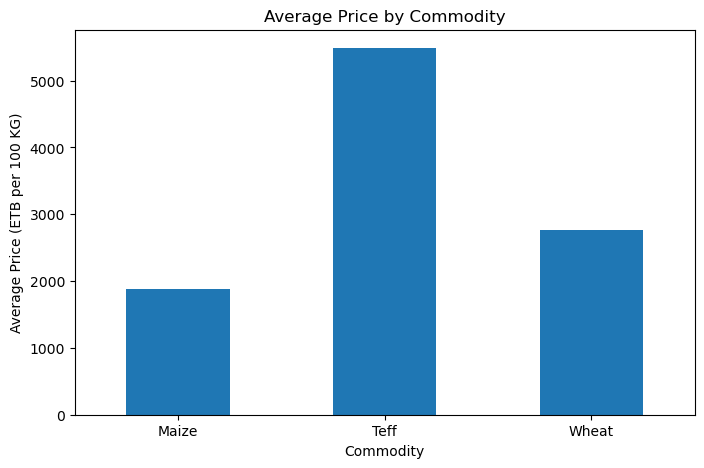

In [ ]:
plt.figure(figsize=(8, 5))

mean_prices = target_df.groupby("commodity_group")["price"].mean()

mean_prices.plot(kind="bar")

plt.title("Average Price by Commodity")
plt.xlabel("Commodity")
plt.ylabel("Average Price (ETB per 100 KG)")
plt.xticks(rotation=0)

plt.show()

2. Median price by commodity

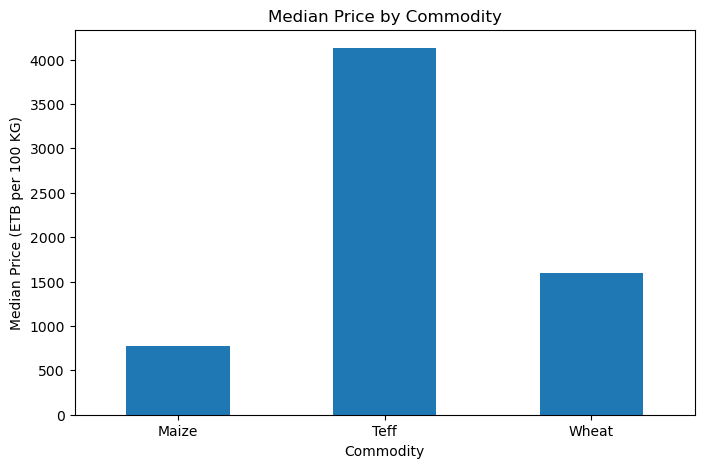

In [ ]:
plt.figure(figsize=(8, 5))

median_prices = target_df.groupby("commodity_group")["price"].median()

median_prices.plot(kind="bar")

plt.title("Median Price by Commodity")
plt.xlabel("Commodity")
plt.ylabel("Median Price (ETB per 100 KG)")
plt.xticks(rotation=0)

plt.show()

3. Price distribution by commodity

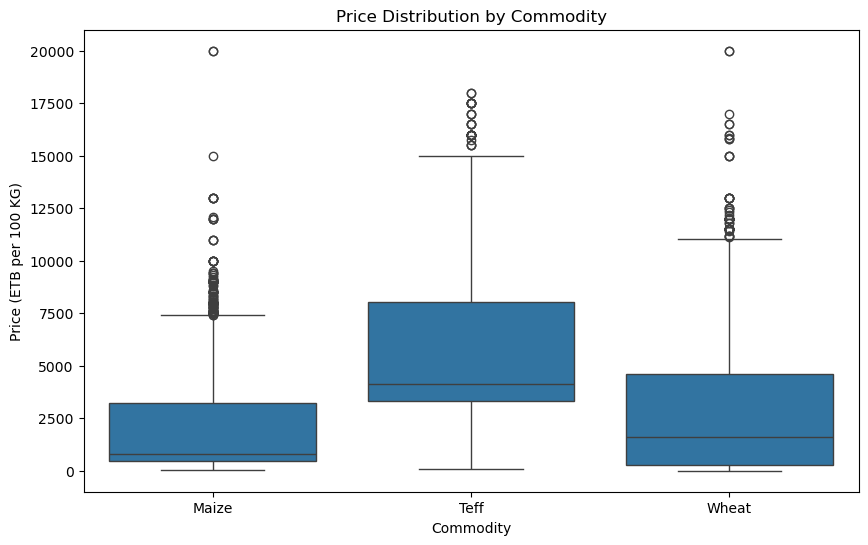

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=target_df,
    x="commodity_group",
    y="price"
)

plt.title("Price Distribution by Commodity")
plt.xlabel("Commodity")
plt.ylabel("Price (ETB per 100 KG)")

plt.show()

In [ ]:
print("Shape:", target_df.shape)

print("\nMissing values:")
print(target_df.isna().sum())

print("\nUnits:")
print(target_df["unit"].value_counts())

print("\nDuplicates:")
print(target_df.duplicated().sum())

print("\nDate range:")
print(target_df["date"].min())
print(target_df["date"].max())

print("\nCommodity groups:")
print(target_df["commodity_group"].value_counts())

Shape: (19115, 17)

Missing values:
date               0
admin1             5
admin2             5
market             0
market_id          0
latitude           5
longitude          5
category           0
commodity          0
commodity_id       0
unit               0
priceflag          0
pricetype          0
currency           0
price              0
usdprice           0
commodity_group    0
dtype: int64

Units:
unit
100 KG    19115
Name: count, dtype: int64

Duplicates:
0

Date range:
2000-01-15 00:00:00
2026-07-15 00:00:00

Commodity groups:
commodity_group
Maize    8704
Wheat    7132
Teff     3279
Name: count, dtype: int64


Inspect

In [ ]:
target_df[target_df["admin1"].isna()]

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,commodity_group
15405,2020-04-15,NaN,NaN,Bichena,3060,NaN,NaN,cereals and tubers,Teff (Sergegna),779,100 KG,actual,Wholesale,ETB,3250.0,98.93,Teff
15406,2020-04-15,NaN,NaN,Bichena,3060,NaN,NaN,cereals and tubers,Teff (white),767,100 KG,actual,Wholesale,ETB,3550.0,108.07,Teff
18703,2020-10-15,NaN,NaN,Bichena,3060,NaN,NaN,cereals and tubers,Maize (white),67,100 KG,actual,Wholesale,ETB,1290.0,34.71,Maize
18704,2020-10-15,NaN,NaN,Bichena,3060,NaN,NaN,cereals and tubers,Teff (Sergegna),779,100 KG,actual,Wholesale,ETB,3665.0,98.63,Teff
18705,2020-10-15,NaN,NaN,Bichena,3060,NaN,NaN,cereals and tubers,Teff (white),767,100 KG,actual,Wholesale,ETB,4035.0,108.58,Teff


In [ ]:
target_df[target_df["market"] == "Bichena"][
    ["market", "admin1", "admin2", "latitude", "longitude"]
].drop_duplicates()

,market,admin1,admin2,latitude,longitude
15405,Bichena,NaN,NaN,NaN,NaN


Five observations had missing geographic information for Bichena market. Since the missing geographic values could not be reliably recovered from the dataset, they were retained as missing rather than being artificially imputed. These observations were retained because the price, date, commodity and market information required for forecasting were available.

### Validate final cleaned dataset

In [58]:
print("Final shape:", target_df.shape)

print("\nMissing values:")
print(target_df.isna().sum())

print("\nDuplicate rows:", target_df.duplicated().sum())

print("\nDate range:")
print(target_df["date"].min(), "to", target_df["date"].max())

print("\nCommodity groups:")
print(target_df["commodity_group"].value_counts())

print("\nUnits:")
print(target_df["unit"].value_counts())

print("\nPrice types:")
print(target_df["pricetype"].value_counts())

Final shape: (19115, 17)

Missing values:
date               0
admin1             5
admin2             5
market             0
market_id          0
latitude           5
longitude          5
category           0
commodity          0
commodity_id       0
unit               0
priceflag          0
pricetype          0
currency           0
price              0
usdprice           0
commodity_group    0
dtype: int64

Duplicate rows: 0

Date range:
2000-01-15 00:00:00 to 2026-07-15 00:00:00

Commodity groups:
commodity_group
Maize    8704
Wheat    7132
Teff     3279
Name: count, dtype: int64

Units:
unit
100 KG    19115
Name: count, dtype: int64

Price types:
pricetype
Retail       12559
Wholesale     6556
Name: count, dtype: int64


## Save cleaned dataset

In [60]:
output_path = "../data/processed/ethiopian_food_prices_cleaned.csv"

target_df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully.")
print("Saved to:", output_path)

Cleaned dataset saved successfully.
Saved to: ../data/processed/ethiopian_food_prices_cleaned.csv


## Data Source

The dataset used in this project is the World Food Programme (WFP) food price
dataset for Ethiopia. It contains historical food price observations across
different commodities, markets, regions, dates, units, and price types.

Source:
World Food Programme (WFP) Food Prices for Ethiopia.